In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np      
from scipy.integrate import complex_ode

from tasks import make_static_sin_task
from encoding_masking import build_masked_input, compute_tdm_params
from Reservoirs.ELM_static import run_elm_static, ELMStaticParams
from readout import split_states_targets, fit_ridge_readout, predict_readout
from metrics import mse, nrmse
from Reservoirs.LangKobayashi import expand_virtual_nodes, simulate_lk, simulate_lk_mini, extract_R_from_E, intensities_after_theta_times, charge_at_theta_intervals

In [2]:
#commonly tuned paramameters
L = 1030
N = 20
eta = 0.01 #input strength
TLk = 10
kappa = 0.0 #feedback 
ridge_alpha = 1e-4*0
washout = 30


#reservoir parameters:
p = 0.05 #normalised injection current/pump rate
alpha = 0 #linewidth enhancemenet factor
phi = 0 #phase shift


xi = 0 #for now, this is time dependant and represents Gaussian noise.
D_noise = 10**-7*0

task_seed = 0
mask_seed = 42


#g = 1.0
split = 0.8

theta = 22
dt = 0.1
tau_factor = 1.41 #as per the Kathy Ludge paper.

TDM_parameters = compute_tdm_params(N, theta, dt, tau_factor)

tap_stride = TDM_parameters.tap_stride
Nd_loop = TDM_parameters.Nd_loop
print(TDM_parameters)

TDMParams(N=20, theta=22, dt=0.1, T=440, tau=620.4, Nd_loop=4400, Nd_delay=6204, tap_stride=220)


In [3]:
x = np.linspace(-1., 1., L)
y = np.sin(2.0 * np.pi * x)
#x, y = task.x, task.y

In [4]:
x_norm, mask, V = build_masked_input(x, N=N, rng=mask_seed) 

In [5]:
tap_stride = TDM_parameters.tap_stride  
Nd_delay = TDM_parameters.Nd_delay    
tau = TDM_parameters.tau


Vs = expand_virtual_nodes(V, tap_stride=tap_stride, Nd=Nd_loop)  
#E_hist, n_hist = simulate_lk(Vs, dt, Nd_delay, alpha=alpha, kappa=kappa, phi=phi, p=p, eta=eta, D_noise=D_noise, xi=xi, Tlk=TLk, E0=1e-3+0j, n0=0.0)
E_hist, n_hist = simulate_lk(Vs, dt, Nd_delay, alpha=alpha, kappa=kappa, phi=phi, p=p, eta=eta, D_noise=D_noise, xi=xi, Tlk=TLk, E0=1e-3+0j, n0=0.0)

In [6]:
R = extract_R_from_E(E_hist, L=L, N=N, tap_stride=tap_stride, Nd_loop=Nd_loop, washout_cycles=washout)

In [7]:
y = y[washout:]
s = split_states_targets(R, y, split=split)
#model = fit_ridge_readout(s.R_train, s.y_train, alpha=ridge_alpha, fit_intercept=False)
model = fit_ridge_readout(s.R_train, s.y_train, alpha= alpha, fit_intercept=True) # trying this to see if fit intercpet true improves performance
y_pred = predict_readout(model, s.R_test)


MSE: 0.0007416494934753538
NRMSE: 0.0964662012208559


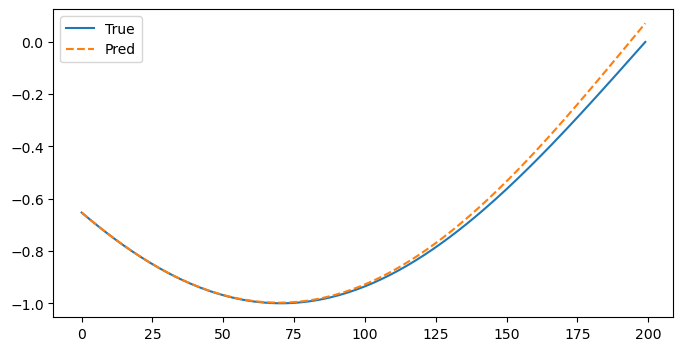

In [8]:
print("MSE:", mse(s.y_test, y_pred))
print("NRMSE:", nrmse(s.y_test, y_pred))

plt.figure(figsize=(8,4))
plt.plot(s.y_test, label="True")
plt.plot(y_pred, "--", label="Pred")
#plt.title("eta=0.01 K=0.005 Tlk=10 a_ridge=0*e^-4. TEST DATA")
plt.legend()
plt.show()

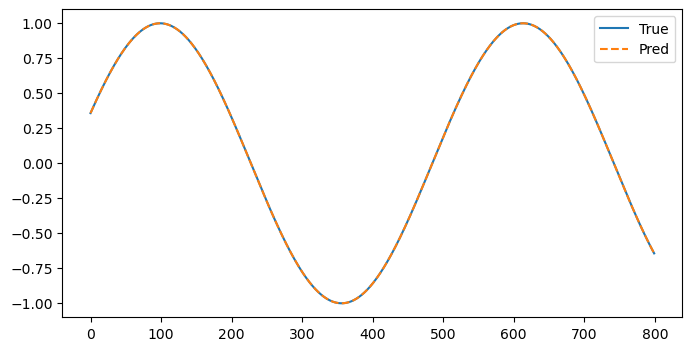

In [9]:
y_pred_train = predict_readout(model, s.R_train)

plt.figure(figsize=(8,4))
plt.plot(s.y_train, label="True")
plt.plot(y_pred_train, "--", label="Pred")
#plt.title("eta=0.01 K=0.005 Tlk=50 a_ridge=0. traindata")
plt.legend()
plt.show()

In [10]:
N_of_thetas = 2000
#E_hist1, n_hist1 = simulate_lk_mini(Vs, dt, Nd_delay, alpha=alpha, kappa=kappa, phi=phi, p=p, eta=0, D_noise=D_noise, xi=xi, Tlk=TLk, E0=1e-3+0j, n0=0.0, N_of_thetas=N_of_thetas, tap_stride=tap_stride)
E_hist1, n_hist1 = simulate_lk_mini(Vs, dt, Nd_delay, alpha=alpha, kappa=kappa, phi=phi, p=p, eta=0, D_noise=D_noise, Tlk=TLk, E0=1e-3+0j, n0=0.0, N_of_thetas=N_of_thetas, tap_stride=tap_stride)

number_of_points = N_of_thetas*tap_stride

R_mini_array = intensities_after_theta_times(E_hist1, N_of_thetas=N_of_thetas, tap_stride=tap_stride, Nd_loop=Nd_loop, washout_cycles=0)
print("R_mini shape:", R_mini_array.shape)

TypeError: simulate_lk_mini() missing 1 required keyword-only argument: 'xi'

In [ ]:
plt.plot(R_mini_array)
plt.xlabel("n multiple of theta")
plt.ylabel("Intensity")
plt.title("eta=0.1 K=0.01 Tlk=10")
plt.grid(True)
plt.show()

In [ ]:
plt.plot(R_mini_array[0:100])
plt.xlabel("n multiple of theta")
plt.ylabel("Intensity")
plt.title("eta=0.0 K=0.01 Tlk=10")
plt.grid(True)
plt.show()

In [ ]:
plt.plot(np.arange(400, 700),R_mini_array[400:700])
plt.xlabel("n multiple of theta")
plt.ylabel("Intensity")
plt.title("eta=0.01 K=0.1 Tlk=50")
plt.grid(True)
plt.show()

In [ ]:
nt_at_theta_intervals = charge_at_theta_intervals(n_hist1, N_of_thetas=N_of_thetas, tap_stride=tap_stride, Nd_loop=Nd_loop, washout_cycles=0)

In [ ]:
plt.plot(nt_at_theta_intervals)
plt.xlabel("n multiple of theta")
plt.ylabel("n(t)")
plt.title("eta=0.01 K=0.1 Tlk=10")
plt.grid(True)
plt.show()